In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
import cv2
from tqdm import tqdm
import datetime

import torch

DATA_PATH = "E:/ML/UBC"
print(DATA_PATH)


E:/ML/UBC


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [3]:
trainList = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
trainList.head()

,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False


In [4]:
from sklearn.preprocessing import LabelEncoder
import pickle

uniqueLabels = trainList["label"].unique()

enc = LabelEncoder()
enc.fit(np.append(uniqueLabels, "Other"))
print(enc.classes_)
print(enc.transform(["LGSC"]))

with open('LabelEncoder.pkl', 'wb') as f:
    pickle.dump(enc, f)

['CC' 'EC' 'HGSC' 'LGSC' 'MC' 'Other']
[3]


In [5]:
print(f"{uniqueLabels=}")

uniqueLabels=array(['HGSC', 'LGSC', 'EC', 'CC', 'MC'], dtype=object)


In [6]:
allFiles = []
stopLoop = False
for root, dirs, files in os.walk(os.path.join(DATA_PATH, "trainProcessed")):
    for f in files:
        if f.endswith(".png") or f.endswith(".jpg") or f.endswith(".JPG") or f.endswith(".jpeg"):
            allFiles.append(os.path.join(root, f))
    
# for root, dirs, files in os.walk(os.path.join(DATA_PATH, "trainProcessed/Kokila")):
#     for f in files:
#         if f.endswith(".png") or f.endswith(".jpg") or f.endswith(".JPG") or f.endswith(".jpeg"):
#             allFiles.append(os.path.join(root, f))
    
len(allFiles)

36320

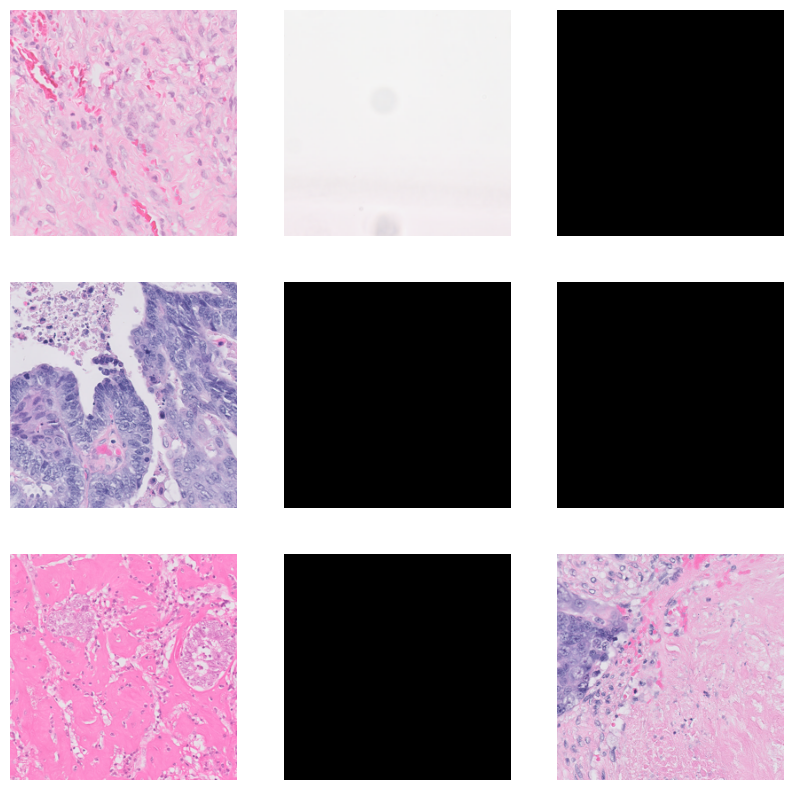

In [7]:

IMG_SIZE = (256, 256)
eps=1e-12

def readImage(path, skipResize=False):
    data = Image.open(path).convert("RGB")
        
    w, h = data.width, data.height
    # centerWindow = data[w//4:3*w//4, h//4:3*h//4]
    # medValue = np.median(data)

    #Center crop
    data = np.array(data)
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w, :]

    # data = data - np.min(data)
    # data = data * 1.0/(np.max(data)+eps)

    w, h, c = data.shape[0], data.shape[1], data.shape[2]

    # resize
    if not skipResize:
        if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
            data = np.array(Image.fromarray(data).resize(IMG_SIZE))
    
    # data = data/(np.max(data)+eps) * 2 - 1

    # data = (data * 255).astype(np.uint8)
    return data



plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(readImage(filePath))
    _ = plt.axis("off")
# plt.colorbar()

In [8]:
import pickle
trainListIndexed= trainList.set_index("image_id")

if os.path.exists(os.path.join(DATA_PATH,"./data.pkl")):
    with open(os.path.join(DATA_PATH,"./data.pkl"), "rb") as f:
        zippedData = pickle.load(f)
        X,y = zip(*zippedData)
else:
    X = []
    y = []
    for i,filePath in enumerate(tqdm(allFiles)):
        if "patches" in filePath:
            parts = filePath.split("\\")
            fileId = int(parts[-2])
            targets = trainListIndexed.loc[fileId]
            label = np.array([targets["label"]])
            encLabel = enc.transform(label)
            im = readImage(filePath)
            hist , _ = np.histogram(im, bins=10, range=(0.0,255.0))
            # If most pixels are very bright or dark the patch is outside the relevant area
            if ((np.sum(hist[2:-2]))/(np.sum(hist)+eps)) < 0.1 or (hist[0])/np.sum(hist)>0.3:
                continue
            X.append(im)
            y.append(encLabel[0])
        elif "Kokila" in filePath:
            if "Clear_Cell" in filePath:
                label = np.array(["CC"])
                encLabel = enc.transform(label)
            elif "Endometri" in filePath:
                label = np.array(["EC"])
                encLabel = enc.transform(label)
            elif "Mucinous" in filePath:
                label = np.array(["MC"])
                encLabel = enc.transform(label)
            elif "Non-Cancerous" in filePath:
                label = np.array(["Other"])
                encLabel = enc.transform(label)
            elif "HGSerous" in filePath:
                label = np.array(["HGSC"])
                encLabel = enc.transform(label)
            elif "LGSerous" in filePath:
                label = np.array(["LGSC"])
                encLabel = enc.transform(label)
            else:
                continue
            im = readImage(filePath)
            hist , _ = np.histogram(im, bins=10, range=(0.0,255.0))
            # If most pixels are very bright or dark the patch is outside the relevant area
            if ((np.sum(hist[2:-2]))/(np.sum(hist)+eps)) < 0.1 or (hist[0])/np.sum(hist)>0.3:
                continue

            X.append(im)
            y.append(encLabel[0])
        else:
            print("invalid folder")

    with open(os.path.join(DATA_PATH,"./data.pkl"), "wb") as f:
        pickle.dump(zip(X,y), f)

print(len(X))

21985


In [9]:
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ColorJitter(0.1, 0.1, 0.1),
    v2.ToDtype(torch.float32),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transformsVal = v2.Compose([
    v2.ToDtype(torch.float32),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

TRAIN_TEST_SPLIT = 0.7

import random
random.seed(186)

split = int(len(X)*TRAIN_TEST_SPLIT)
print("# Training samples:",split)
dataShuffled = list(zip(X,y))
random.shuffle(dataShuffled)
trainData = dataShuffled[0:split]
valData = dataShuffled[split::]


def generator():
    for im, label in trainData:
        im = np.swapaxes(np.array(im), 0,-1).astype(np.float32)/255.0
        im = transforms(torch.Tensor(im))
        yield im, label.astype(np.int64)


def generatorVal():
    for imVal, labelVal in valData:
        imVal = np.swapaxes(np.array(imVal), 0,-1).astype(np.float32)/255.0
        imVal = transformsVal(torch.Tensor(imVal))
        yield imVal, labelVal.astype(np.int64)

# def generatorAll():
#     for id in allIds:
#         yield getData(id)

# Training samples: 15389


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\transforms\v2\__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you m

tensor(0.1460) tensor(1.)
torch.Size([3, 256, 256])
0


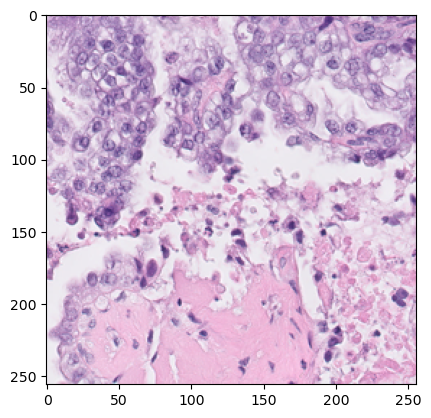

In [10]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

plt.imshow(torch.moveaxis(testInstance[0], 0,-1))
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])

In [11]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainData))
datasetVal = IterDataset(generatorVal, len(valData))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
for XData, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([32, 3, 256, 256]) torch.float32
Max and Min:  tensor(1.) tensor(0.0114)
Shape of target: torch.Size([32]) torch.int64


tensor(1)


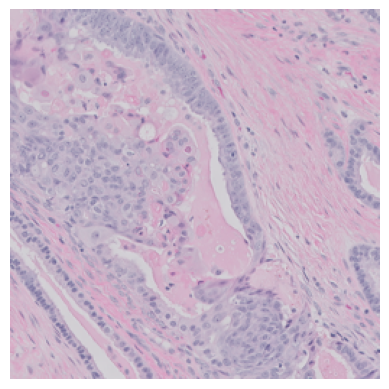

In [13]:
idx=2
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(torch.moveaxis(XData, 1,-1)[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [14]:
from torch import nn
import torchinfo
from torch import nn
import torch
from modelZoo.models import Res2DModel, ResNet2DModel, ResNet34

Dropout=0.05
HIDDEN_DIM=512
K=2

    
# model = Res2DModel(len(enc.classes_), channels=3, name="Res2DModelPatches_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False)
# model = ResNet2DModel(len(enc.classes_), inputDim=IMG_SIZE[0], channels=3, name="ResNet2DModelPatches_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False, useGAP=True)
model = ResNet34(len(enc.classes_), inputDim=IMG_SIZE[0], channels=3, name="ResNet34Patches", K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False, useGAP=True)
#TODO: Pretrained model


from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
model.safetensors: 100%|██████████| 87.3M/87.3M [00:07<00:00, 11.3MB/s]
c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Manuel\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as

Layer (type:depth-idx)                        Output Shape              Param #
ResNet34                                      [32, 6]                   --
├─FeatureListNet: 1-1                         [32, 512, 8, 8]           --
│    └─Conv2d: 2-1                            [32, 64, 128, 128]        9,408
│    └─BatchNorm2d: 2-2                       [32, 64, 128, 128]        128
│    └─ReLU: 2-3                              [32, 64, 128, 128]        --
│    └─MaxPool2d: 2-4                         [32, 64, 64, 64]          --
│    └─Sequential: 2-5                        [32, 64, 64, 64]          --
│    │    └─BasicBlock: 3-1                   [32, 64, 64, 64]          73,984
│    │    └─BasicBlock: 3-2                   [32, 64, 64, 64]          73,984
│    │    └─BasicBlock: 3-3                   [32, 64, 64, 64]          73,984
│    └─Sequential: 2-6                        [32, 128, 32, 32]         --
│    │    └─BasicBlock: 3-4                   [32, 128, 32, 32]         230,144

In [15]:
# model_graph.visual_graph

In [15]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "Res2DModelPatches_K_8_epoch_86.pt"), map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    # optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

In [16]:

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets ):
        
        #comment out if your model contains a sigmoid or equivalent activation layer
        # inputs = F.sigmoid(inputs)       
        
        #flatten label and prediction tensors
        # inputs = inputs.view(-1)
        # targets = targets.view(-1)
        
        #compute cross-entropy 
        CE = torch.nn.functional.cross_entropy(inputs, targets, reduction="none")
        CEExp = torch.exp(-CE)
        focal_loss = self.alpha * (1-CEExp)**self.gamma * CE
                       
        return focal_loss.mean()
    
testF = FocalLoss()
testF(torch.Tensor([[-10,4,-2], [-10,0,-2]]), torch.Tensor([1,1]).type(dtype=torch.int64))

tensor(0.0007)

In [17]:
from torcheval import metrics
from torch.utils.tensorboard import SummaryWriter
from torchmetrics import AUROC, Accuracy


LOG_INTERVAL=5
epochs = 60
EARLY_STOPPING_PATIENCE=8
saveModel=False


log_dir = "./logs/"+model.name+"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter(log_dir)

# Instantiate an optimizer .
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Instantiate a loss function.
# lossFn = torch.nn.CrossEntropyLoss()
lossFn = FocalLoss()


# accMetric = tf.keras.metrics.BinaryAccuracy()
accMetric = Accuracy(task="multiclass", num_classes=len(enc.classes_), average="micro").to(device)
aurocMetric = AUROC(task="multiclass", num_classes=len(enc.classes_)).to(device)
# f1Metric = tf.keras.metrics.F1Score(threshold=0.5, average="micro")

accMetricVal = Accuracy(task="multiclass", num_classes=len(enc.classes_), average=None).to(device)

# optimizer = torch.optim.SGD(model.parameters(), lr=0.004, momentum=0.9)

def train(dataloaderTrain, model, optimizer, epoch):
    size = len(dataloaderTrain.dataset)
    model.train()
    for batch, (XTrain, yTrain) in enumerate(dataloaderTrain):
        # XTrain = XTrain.movedim(-1,1)
        XTrain, yTrain = XTrain.to(device), yTrain.to(device)
        pred = model(XTrain)
        # targetLabel = torch.argmax(y, dim=1)
        
        loss = lossFn(pred, yTrain)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # scheduler.step()

        accMetric.update(pred, yTrain)
        aurocMetric.update(pred, yTrain)
        
        if batch % LOG_INTERVAL == 0:
            loss = loss.item()
            print("loss: {:>5f}, acc: {:.4f}, AUROC: {:.4f}  [{:>5d}/{:>5d}]".format(loss, accMetric.compute(),  aurocMetric.compute(), batch*BATCH_SIZE, size))
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Acc", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("AUROC", aurocMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()



def validate(dataloaderVal, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (XVal, yVal) in enumerate(dataloaderVal):
        # XVal = XVal.movedim(-1,1)
        XVal, yVal = XVal.to(device), yVal.to(device)
        predVal = model(XVal)
        # targetLabel = torch.argmax(y, dim=1)
        lossAdd = lossFn(predVal, yVal)
        loss += lossAdd.detach().cpu().numpy()
        accMetricVal.update(predVal, yVal)
        
    lossVal = loss.item()/(batch+1)
    print("Weighted Avg Cross Entropy: {:>7f}".format(lossVal))
    print("Accuracy: {:>7f}".format(torch.mean(accMetricVal.compute())))
    summary_writer.add_scalar("Val BCE", lossVal, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.flush()
    fig, ax = accMetricVal.plot()
    fig.savefig(os.path.join(DATA_PATH, "metricPlots", "accuracy_{}.png".format(epoch)))
    plt.close()
    return torch.mean(accMetricVal.compute())


bestValAcc=0.0
bestEpoch=0

for t in np.arange(startEpoch, startEpoch+epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train(trainLoader, model, optimizer, t)
    accMetric.reset()
    aurocMetric.reset()

    avgAccVal = validate(valLoader, model, t)
    accMetricVal.reset()

    if saveModel:
        model_scripted = torch.jit.script(model) # Export to TorchScript
        fileName = "{}_epoch{}_CE{:.4f}.pt".format(model.name, t, avgAccVal)
        model_scripted.save(os.path.join(DATA_PATH, fileName))
    
    #Early stopping
    if avgAccVal > bestValAcc:
        bestValAcc = avgAccVal
        bestEpoch = t
        bestWeights = model.state_dict()
    if t - bestEpoch >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

    print("LR: {:.2E}".format(optimizer.state_dict()["param_groups"][0]["lr"]))
    
print("Done!")
print("Best Val Acc: ", bestValAcc.detach().cpu().numpy())

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchaudio\backend\utils.py:74: UserWarning: No audio backend is available.
  warnings.warn("No audio backend is available.")


Epoch 1
-------------------------------


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


loss: 1.007300, acc: 0.2188, AUROC: 0.4375  [    0/15389]
loss: 0.962624, acc: 0.2240, AUROC: 0.4112  [  160/15389]
loss: 0.920223, acc: 0.2443, AUROC: 0.4887  [  320/15389]
loss: 0.875437, acc: 0.3027, AUROC: 0.5290  [  480/15389]
loss: 0.757664, acc: 0.3378, AUROC: 0.5299  [  640/15389]
loss: 0.856216, acc: 0.3510, AUROC: 0.5223  [  800/15389]
loss: 0.806581, acc: 0.3548, AUROC: 0.5320  [  960/15389]
loss: 0.836078, acc: 0.3681, AUROC: 0.5234  [ 1120/15389]
loss: 0.706383, acc: 0.3742, AUROC: 0.5280  [ 1280/15389]
loss: 0.664784, acc: 0.3845, AUROC: 0.5272  [ 1440/15389]
loss: 0.806834, acc: 0.3848, AUROC: 0.5341  [ 1600/15389]
loss: 0.685330, acc: 0.3817, AUROC: 0.5472  [ 1760/15389]
loss: 0.723274, acc: 0.3822, AUROC: 0.5521  [ 1920/15389]
loss: 0.727192, acc: 0.3826, AUROC: 0.5432  [ 2080/15389]
loss: 0.655972, acc: 0.3781, AUROC: 0.5457  [ 2240/15389]
loss: 0.639413, acc: 0.3808, AUROC: 0.5432  [ 2400/15389]
loss: 0.747684, acc: 0.3827, AUROC: 0.5499  [ 2560/15389]
loss: 0.803751

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


...

loss: 0.005107, acc: 1.0000, AUROC: 0.8333  [    0/15389]
loss: 0.001189, acc: 0.9844, AUROC: 0.8332  [  160/15389]
loss: 0.004657, acc: 0.9886, AUROC: 0.9996  [  320/15389]
loss: 0.006910, acc: 0.9883, AUROC: 0.9996  [  480/15389]
loss: 0.009863, acc: 0.9851, AUROC: 0.9997  [  640/15389]
loss: 0.000715, acc: 0.9844, AUROC: 0.9997  [  800/15389]
loss: 0.002786, acc: 0.9839, AUROC: 0.9997  [  960/15389]
loss: 0.168422, acc: 0.9844, AUROC: 0.9993  [ 1120/15389]
loss: 0.003149, acc: 0.9863, AUROC: 0.9994  [ 1280/15389]
loss: 0.026762, acc: 0.9871, AUROC: 0.9995  [ 1440/15389]
loss: 0.002085, acc: 0.9859, AUROC: 0.9995  [ 1600/15389]
loss: 0.005378, acc: 0.9866, AUROC: 0.9995  [ 1760/15389]
loss: 0.002793, acc: 0.9872, AUROC: 0.9995  [ 1920/15389]
loss: 0.000784, acc: 0.9863, AUROC: 0.9995  [ 2080/15389]
loss: 0.004289, acc: 0.9872, AUROC: 0.9995  [ 2240/15389]
loss: 0.003388, acc: 0.9860, AUROC: 0.9995  [ 2400/15389]
loss: 0.007618, acc: 0.9865, AUROC: 0.9996  [ 2560/15389]
loss: 0.008524

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


loss: 0.011521, acc: 0.9688, AUROC: 0.8333  [    0/15389]
loss: 0.001728, acc: 0.9792, AUROC: 0.8332  [  160/15389]
loss: 0.005540, acc: 0.9886, AUROC: 0.9999  [  320/15389]
loss: 0.015735, acc: 0.9844, AUROC: 0.9997  [  480/15389]
loss: 0.008663, acc: 0.9851, AUROC: 0.9996  [  640/15389]
loss: 0.005776, acc: 0.9868, AUROC: 0.9997  [  800/15389]
loss: 0.056571, acc: 0.9859, AUROC: 0.9997  [  960/15389]
loss: 0.036126, acc: 0.9852, AUROC: 0.9997  [ 1120/15389]
loss: 0.003192, acc: 0.9855, AUROC: 0.9997  [ 1280/15389]
loss: 0.002637, acc: 0.9844, AUROC: 0.9996  [ 1440/15389]
loss: 0.003721, acc: 0.9859, AUROC: 0.9997  [ 1600/15389]
loss: 0.003733, acc: 0.9860, AUROC: 0.9997  [ 1760/15389]
loss: 0.001445, acc: 0.9862, AUROC: 0.9997  [ 1920/15389]
loss: 0.005650, acc: 0.9858, AUROC: 0.9997  [ 2080/15389]
loss: 0.003432, acc: 0.9859, AUROC: 0.9997  [ 2240/15389]
loss: 0.000904, acc: 0.9868, AUROC: 0.9998  [ 2400/15389]
loss: 0.012968, acc: 0.9861, AUROC: 0.9998  [ 2560/15389]
loss: 0.023040

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


loss: 0.005362, acc: 1.0000, AUROC: 0.8333  [    0/15389]
loss: 0.035701, acc: 0.9583, AUROC: 0.8325  [  160/15389]
loss: 0.039742, acc: 0.9659, AUROC: 0.9990  [  320/15389]
loss: 0.000864, acc: 0.9766, AUROC: 0.9993  [  480/15389]
loss: 0.015174, acc: 0.9792, AUROC: 0.9994  [  640/15389]
loss: 0.000784, acc: 0.9820, AUROC: 0.9995  [  800/15389]
loss: 0.003152, acc: 0.9829, AUROC: 0.9996  [  960/15389]
loss: 0.016993, acc: 0.9835, AUROC: 0.9996  [ 1120/15389]
loss: 0.017366, acc: 0.9840, AUROC: 0.9996  [ 1280/15389]
loss: 0.016332, acc: 0.9830, AUROC: 0.9995  [ 1440/15389]
loss: 0.008026, acc: 0.9828, AUROC: 0.9996  [ 1600/15389]
loss: 0.011175, acc: 0.9838, AUROC: 0.9996  [ 1760/15389]
loss: 0.006562, acc: 0.9846, AUROC: 0.9996  [ 1920/15389]
loss: 0.029748, acc: 0.9844, AUROC: 0.9996  [ 2080/15389]
loss: 0.004203, acc: 0.9842, AUROC: 0.9997  [ 2240/15389]
loss: 0.029405, acc: 0.9836, AUROC: 0.9997  [ 2400/15389]
loss: 0.027409, acc: 0.9838, AUROC: 0.9997  [ 2560/15389]
loss: 0.005608

In [18]:
model.load_state_dict(bestWeights)

<All keys matched successfully>

In [19]:
torch.save({
    'epoch': t,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    # 'scheduler_state_dict': scheduler.state_dict(),
    # 'loss': loss,
    }, os.path.join("./", model.name+"_epoch_{}.pt".format(t)))

In [20]:
model_scripted = torch.jit.script(model) # Export to TorchScript
model_scripted.save('{}_scripted.pt'.format(model.name)) # Save

# modelCPU = model.to("cpu")
# modelCPU_scripted = torch.jit.script(modelCPU) # Export to TorchScript
# modelCPU_scripted.save('{}_scriptedCPU.pt'.format(model.name)) # Save

### Testing

(array([4096., 5309., 8878., 1822., 1826.,   54.]),
 array([0.        , 0.83333333, 1.66666667, 2.5       , 3.33333333,
        4.16666667, 5.        ]),
 <BarContainer object of 6 artists>)

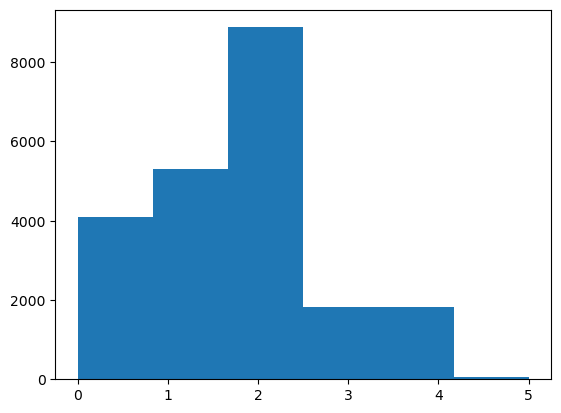

In [21]:
plt.hist(y, bins=len(enc.classes_))

In [22]:
for i,(XTest,yTest) in enumerate(trainLoader):
    if i == 2:
        break

TypeError: Invalid shape (3, 256, 256) for image data

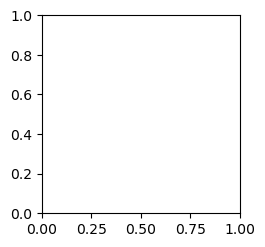

In [23]:
plt.figure(figsize=(18,18))

for i in range(5):
    for j in range(5):
        plt.subplot(6,6,i*6+j+1)
        plt.imshow(XTest[i*6+j,:,:,:])
        _=plt.axis("off")

TypeError: Invalid shape (3, 256, 256) for image data

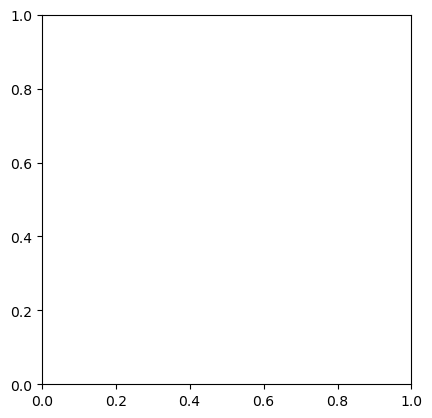

In [24]:
idx = 9
hist , _ = np.histogram(XTest[idx,:,:,:], bins=10, range=(0.0,1.0))
plt.imshow(XTest[idx,:,:,:])
print((hist[0])/np.sum(hist))
print((hist[0] + hist[-1])/np.sum(hist))
print((np.sum(hist[2:-2]))/np.sum(hist))
hist